# SPDAP Project Explanation Notebook

This notebook explains **SPDAP (Silicon Photonics Data Analysis Automation Pipeline)**.

The project analyzes wafer-scale MZM (Mach-Zehnder Modulator) XML measurement data and generates organized analysis outputs.

Main outputs:

- Parsed XML measurement data
- Optical spectrum and IV analysis
- Extracted metrics such as Extinction Ratio, Vpi, FSR, and fitting quality
- Die-level analysis PNG files
- Wafer-level wafermap PNG files
- Summary CSV files

## 1. Project Summary

This project reads `*LMZ*.xml` measurement files under the `data/` directory, analyzes optical and electrical characteristics of MZM devices, and stores the results under `res/csv/` and `res/png/`.

## 2. How to Run

Install dependencies and run the main script:

```bash
pip install -r requirements.txt
python run.py
```

`run.py` calls `src.main.main()`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "run.py").exists()),
    Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

data_dir = PROJECT_ROOT / "data"
xml_files = sorted(data_dir.rglob("*LMZ*.xml"))

print((PROJECT_ROOT / "run.py").read_text(encoding="utf-8"))
print("Project root:", PROJECT_ROOT)
print("LMZ XML file count:", len(xml_files))

from src.main import main as run_mzm_analysis

if __name__ == "__main__":
    run_mzm_analysis()

Project root: C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1
LMZ XML file count: 98


## 3. Pipeline Flow

This pipeline first searches the `data/` directory for LMZ XML measurement files.

The files are then analyzed by the modules in `src/`, and the analysis results are converted into PNG graphs and CSV summary files.

Finally, the wafer-level results are combined into a wafermap and all outputs are saved under the `res/` directory.

Flow:

1. Find `*LMZ*.xml` files in `data/`.
2. Analyze the XML data using the code in `src/`.
3. Generate PNG graphs and CSV summary files.
4. Create the wafermap from the analyzed wafer data.
5. Save the final outputs under `res/`.

In [2]:
from src.main import measurement_folders

folders = measurement_folders(data_dir)
print("Measurement folder count:", len(folders))
print("First 10 measurement folders:")
for wafer, timestamp in folders[:10]:
    print(f"- wafer={wafer}, timestamp={timestamp}")

Measurement folder count: 11
First 10 measurement folders:
- wafer=D07, timestamp=20190715_190855
- wafer=D08, timestamp=20190526_082853
- wafer=D08, timestamp=20190528_001012
- wafer=D08, timestamp=20190712_113254
- wafer=D23, timestamp=20190528_101900
- wafer=D23, timestamp=20190531_072042
- wafer=D23, timestamp=20190603_204847
- wafer=D24, timestamp=20190528_105459
- wafer=D24, timestamp=20190528_111731
- wafer=D24, timestamp=20190531_151815


## 4. XML Parsing

`src/xml_parser.py` provides `load_xml()`, which extracts two main data groups:

- `sweeps`: wavelength (`L`), insertion loss (`IL`), and DC bias from `WavelengthSweep` nodes
- `iv`: voltage/current arrays from `IVMeasurement` nodes

The next cell parses one sample XML file and prints its basic shape.

In [3]:
from src.xml_parser import load_xml

if xml_files:
    sample_xml = xml_files[0]
    root, sweeps, iv = load_xml(sample_xml)
    print("Sample XML:", sample_xml)
    print("Sweep count:", len(sweeps))
    print("IV voltage points:", len(iv["V"]))
    print("IV current points:", len(iv["I"]))
    if sweeps:
        first = sweeps[0]
        print("First sweep bias:", first["Bias"])
        print("First sweep wavelength points:", len(first["L"]))
        print("First sweep IL points:", len(first["IL"]))
else:
    print("No LMZ XML files found under data/.")

Sample XML: C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1\data\HY202103\D07\20190715_190855\HY202103_D07_(-1,-1)_LION1_DCM_LMZC.xml
Sweep count: 7
IV voltage points: 13
IV current points: 13
First sweep bias: -2.0
First sweep wavelength points: 5000
First sweep IL points: 5000


## 5. CSV Output Schema

CSV columns are defined in `src/config.py` as `CSV_COLUMNS`.

Important fields include:

- wafer, die column, die row, timestamp, and device name
- current values near -1 V, 0 V, and +1 V
- insertion loss minimum, maximum, and mean
- extinction ratio
- modulation fitting R2
- Vpi mean, minimum, and maximum
- source XML file path

In [4]:
from src.config import CSV_COLUMNS

print("CSV column count:", len(CSV_COLUMNS))
for col in CSV_COLUMNS:
    print("-", col)

CSV column count: 12
- lot
- wafer
- test_site
- die_column
- die_row
- timestamp
- device_name
- dc_bias_v
- current_a
- extinction_ratio_db
- vpi_at_dc_bias_v
- source_file


## 6. Example CSV Rows from One XML File

This cell does not run the full pipeline. It only extracts summary rows from the first XML file.

In [5]:
from src.csv_export import summarize_xml
import pandas as pd

if xml_files:
    rows = summarize_xml(xml_files[0])
    print("Rows extracted from sample XML:", len(rows))
    display(pd.DataFrame(rows).head())
else:
    print("No XML files available.")

Rows extracted from sample XML: 6


,lot,wafer,test_site,die_column,die_row,timestamp,device_name,dc_bias_v,current_a,wavelength_start_nm,...,extinction_ratio_db,modulation_null_count,modulation_fsr_nm,modulation_mean_abs_dlambda_dv_nm_per_v,modulation_mean_dlambda_dv_nm_per_v,modulation_dlambda_dv_by_null_nm_per_v,modulation_null_wavelengths_0v_nm,vpi_mean_v,vpi_at_dc_bias_v,source_file
0,HY202103,D07,DCM_LMZC,-1,-1,20190715_190855,MZMCTE_LULAB_450_500,-2.0,3.286373e-08,1530.0003,...,38.244102,3,4.66655,0.218337,-0.218337,-0.230589;-0.190771;-0.233651,1536.8163;1550.8419;1565.3541,10.7786,18.8874,C:\Users\kdm16_korqogl\PycharmProjects\PythonP...
1,HY202103,D07,DCM_LMZC,-1,-1,20190715_190855,MZMCTE_LULAB_450_500,-1.5,3.079262e-08,1530.0007,...,36.976251,3,4.66655,0.218337,-0.218337,-0.230589;-0.190771;-0.233651,1536.8163;1550.8419;1565.3541,10.7786,14.4152,C:\Users\kdm16_korqogl\PycharmProjects\PythonP...
2,HY202103,D07,DCM_LMZC,-1,-1,20190715_190855,MZMCTE_LULAB_450_500,-1.0,2.603237e-08,1530.0006,...,37.653721,3,4.66655,0.218337,-0.218337,-0.230589;-0.190771;-0.233651,1536.8163;1550.8419;1565.3541,10.7786,11.7538,C:\Users\kdm16_korqogl\PycharmProjects\PythonP...
3,HY202103,D07,DCM_LMZC,-1,-1,20190715_190855,MZMCTE_LULAB_450_500,-0.5,1.573456e-08,1530.0003,...,58.590502,3,4.66655,0.218337,-0.218337,-0.230589;-0.190771;-0.233651,1536.8163;1550.8419;1565.3541,10.7786,9.95994,C:\Users\kdm16_korqogl\PycharmProjects\PythonP...
4,HY202103,D07,DCM_LMZC,-1,-1,20190715_190855,MZMCTE_LULAB_450_500,0.0,3.873178e-11,1530.0010,...,58.531833,3,4.66655,0.218337,-0.218337,-0.230589;-0.190771;-0.233651,1536.8163;1550.8419;1565.3541,10.7786,8.65858,C:\Users\kdm16_korqogl\PycharmProjects\PythonP...


## 7. Individual Graph Examples: D08 / 20190712_113254 / Die (0,0)

This section shows each graph separately for one example die.

Example target:

| Field | Value |
|---|---|
| Wafer | `D08` |
| Timestamp | `20190712_113254` |
| Die coordinate | `(0,0)` |
| Device file | `HY202103_D08_(0,0)_LION1_DCM_LMZC.xml` |

Panel layout:

```text
┌──────────────────────┬──────────────────────┬──────────────────────┐
│ (0,0) Transmission   │ (0,1) Reference Fit  │ (0,2) Flattened      │
│       as measured    │       (3rd order)    │       spectra        │
├──────────────────────┼──────────────────────┼──────────────────────┤
│ (1,0) MZM Linear     │ (1,1) IV Log scale   │ (1,2) IV Analysis    │
│       FSR fit        │       fitting        │                      │
├──────────────────────┼──────────────────────┼──────────────────────┤
│ (2,0) MZM dB         │ (2,1) Vπ Voltage     │ (2,2) Extinction     │
│       Residual fit   │       curves         │       Ratio vs Bias  │
└──────────────────────┴──────────────────────┴──────────────────────┘
```

In [6]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy.optimize import curve_fit

from src.config import MOD_BIAS
from src.xml_parser import load_xml, pick_sweep, sweep_label, r2_score
from src.spectrum import mzi_model, measure_fsr, flatten_to_envelope, device_fsr_fallback
from src.iv_analysis import plot_iv_log, plot_iv_analysis
from src.vpi_analysis import plot_vpi_voltage_panels
from src.extinction_ratio import plot_extinction_ratio_panels
from src.main import plot_mzm_db_residual_fit

def show_figure(fig):
    """Render a Matplotlib figure inside the notebook without writing a file."""
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.set_facecolor("white")
        ax.title.set_color("black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.tick_params(colors="black")
        for spine in ax.spines.values():
            spine.set_color("black")
        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor("white")
            legend.get_frame().set_edgecolor("black")
            for text in legend.get_texts():
                text.set_color("black")
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=150, bbox_inches="tight", facecolor="white")
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

example_xml = PROJECT_ROOT / "data/HY202103/D08/20190712_113254/HY202103_D08_(0,0)_LION1_DCM_LMZC.xml"

root, sweeps, iv = load_xml(example_xml)
ref = sweeps[-1]
ref_l = ref["L"]
ref_il = ref["IL"]
poly_func = np.poly1d(np.polyfit(ref_l, ref_il, 3))
fsr_fallback = device_fsr_fallback(root)

print("Example XML:", example_xml)
print("Sweep count:", len(sweeps))

Example XML: C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1\data\HY202103\D08\20190712_113254\HY202103_D08_(0,0)_LION1_DCM_LMZC.xml
Sweep count: 7


### 7.1 Raw Transmission Spectra

This plot shows the measured insertion-loss spectra for all DC-bias sweeps before normalization.

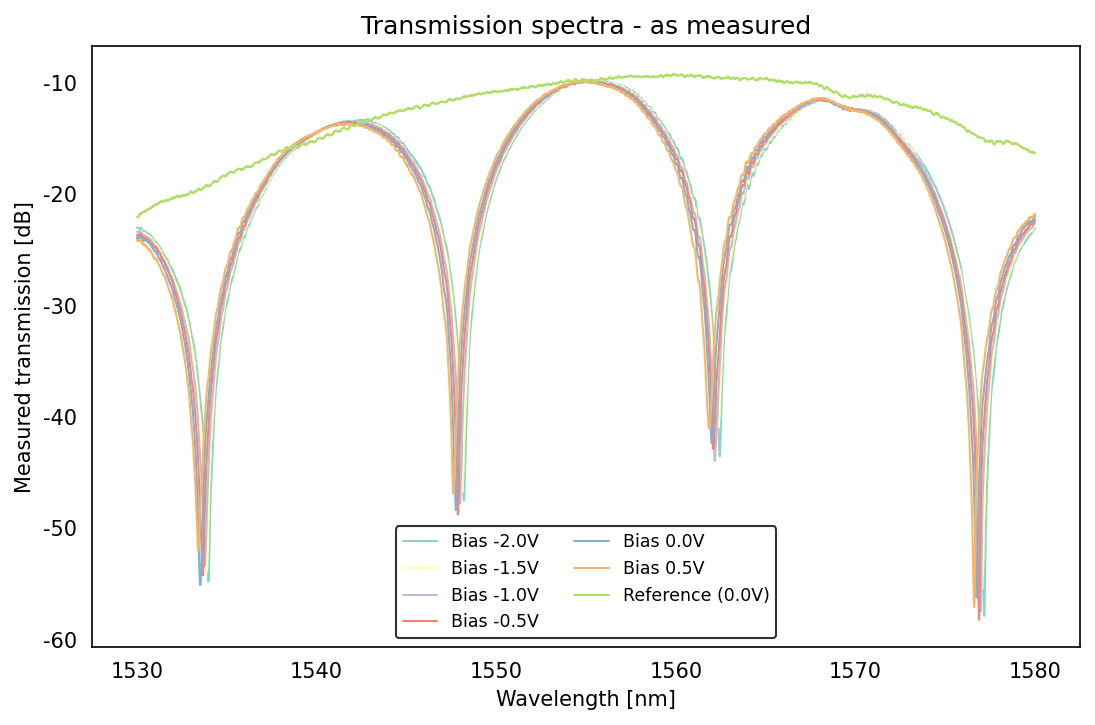

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for index, sweep in enumerate(sweeps):
    ax.plot(sweep["L"], sweep["IL"], label=sweep_label(sweep, index, len(sweeps)), linewidth=1.0)
ax.set_title("Transmission spectra - as measured")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Measured transmission [dB]")
ax.legend(ncol=2, fontsize="small", loc="lower center")
ax.grid(True, ls="--", alpha=0.5)
show_figure(fig)

### 7.2 Reference Fit

The reference sweep is fitted with a third-order polynomial and used as a baseline for normalization.

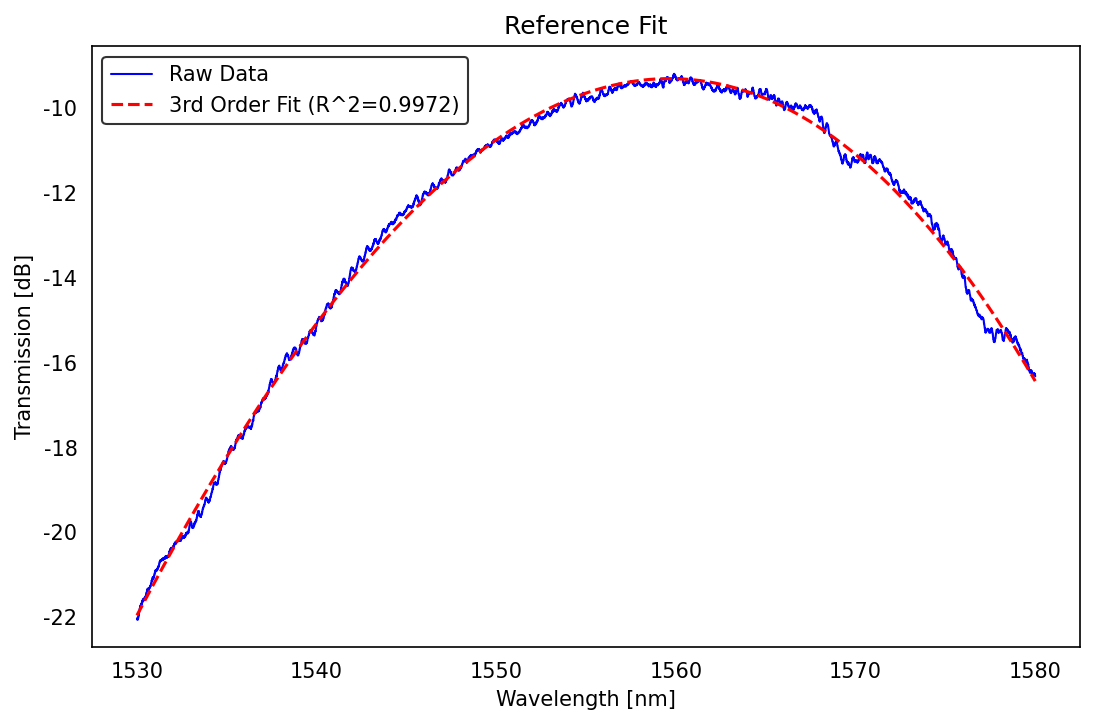

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ref_fit = poly_func(ref_l)
r2_ref = r2_score(ref_il, ref_fit)
ax.plot(ref_l, ref_il, "b", label="Raw Data", linewidth=1.0)
ax.plot(ref_l, ref_fit, "r--", label=f"3rd Order Fit (R^2={r2_ref:.4f})")
ax.set_title("Reference Fit")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Transmission [dB]")
ax.legend()
ax.grid(True, ls="--", alpha=0.5)
show_figure(fig)

### 7.3 Flattened Spectra

This graph removes the reference baseline and envelope trend so modulation fringes can be compared more easily.

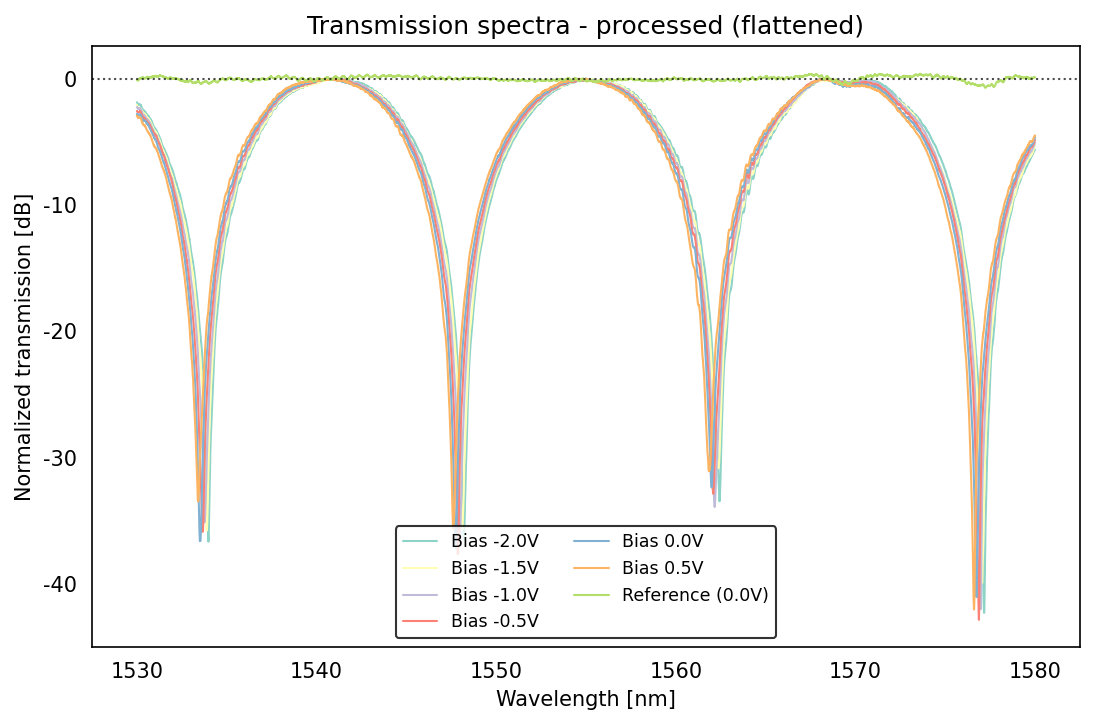

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for index, sweep in enumerate(sweeps):
    wavelength = sweep["L"]
    il = sweep["IL"]
    processed = il - poly_func(wavelength)
    if index == len(sweeps) - 1:
        flattened = processed
    else:
        fsr = measure_fsr(wavelength, processed, fallback=fsr_fallback)
        flattened = flatten_to_envelope(wavelength, processed, fsr)
    ax.plot(wavelength, flattened, label=sweep_label(sweep, index, len(sweeps)), linewidth=1.0)
ax.axhline(0.0, color="black", ls=":", lw=1.0, alpha=0.7)
ax.set_title("Transmission spectra - processed (flattened)")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Normalized transmission [dB]")
ax.legend(ncol=2, fontsize="small", loc="lower center")
ax.grid(True, ls="--", alpha=0.5)
show_figure(fig)

### 7.4 MZM Linear-Domain Fit

This plot converts the selected modulation-bias sweep to linear transmission and fits an MZI model.

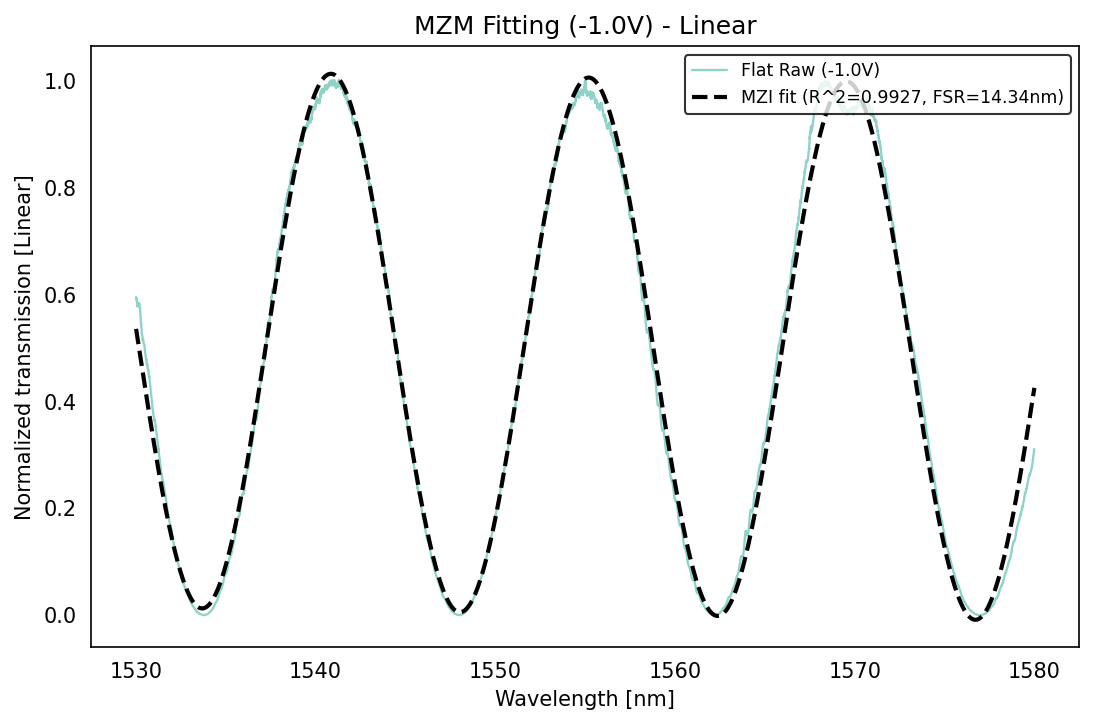

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
mzm = pick_sweep(sweeps, MOD_BIAS)
if mzm is not None:
    wavelength = mzm["L"]
    il = mzm["IL"]
    proc_db = il - poly_func(wavelength)
    fsr0 = measure_fsr(wavelength, proc_db, fallback=fsr_fallback)
    proc_db = flatten_to_envelope(wavelength, proc_db, fsr0)
    transmission = 10 ** (proc_db / 10.0)
    t_low = float(np.nanpercentile(transmission, 5))
    t_high = float(np.nanpercentile(transmission, 95))
    span = max(t_high - t_low, 1e-3)
    p0 = [t_low, span, float(wavelength[np.nanargmax(transmission)]), fsr0, 0.0, 0.0]
    bounds = (
        [max(-0.5, t_low - span), span * 0.05, float(wavelength[0] - fsr0), fsr0 * 0.65, -np.pi, -0.05],
        [max(2.0, t_high + span), max(2.0, span * 3.0), float(wavelength[-1] + fsr0), fsr0 * 1.45, np.pi, 0.05],
    )
    ax.plot(wavelength, transmission, color="C0", linewidth=1.1, label=f"Flat Raw ({MOD_BIAS}V)")
    try:
        popt, _ = curve_fit(mzi_model, wavelength, transmission, p0=p0, bounds=bounds, maxfev=20000)
        fit = mzi_model(wavelength, *popt)
        r2 = r2_score(transmission, fit)
        ax.plot(wavelength, fit, "--", color="black", lw=2, label=f"MZI fit (R^2={r2:.4f}, FSR={popt[3]:.2f}nm)")
    except Exception as exc:
        ax.text(0.5, 0.5, f"Fitting Failed\n{exc}", transform=ax.transAxes, ha="center", va="center", color="red")
else:
    ax.text(0.5, 0.5, f"Bias {MOD_BIAS}V not found", transform=ax.transAxes, ha="center", va="center", color="red")
ax.set_title(f"MZM Fitting ({MOD_BIAS}V) - Linear")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Normalized transmission [Linear]")
ax.legend(loc="upper right", fontsize="small")
ax.grid(True, ls="--", alpha=0.5)
show_figure(fig)

### 7.5 IV Curve on Log Scale

This graph shows absolute current versus voltage on a logarithmic scale.

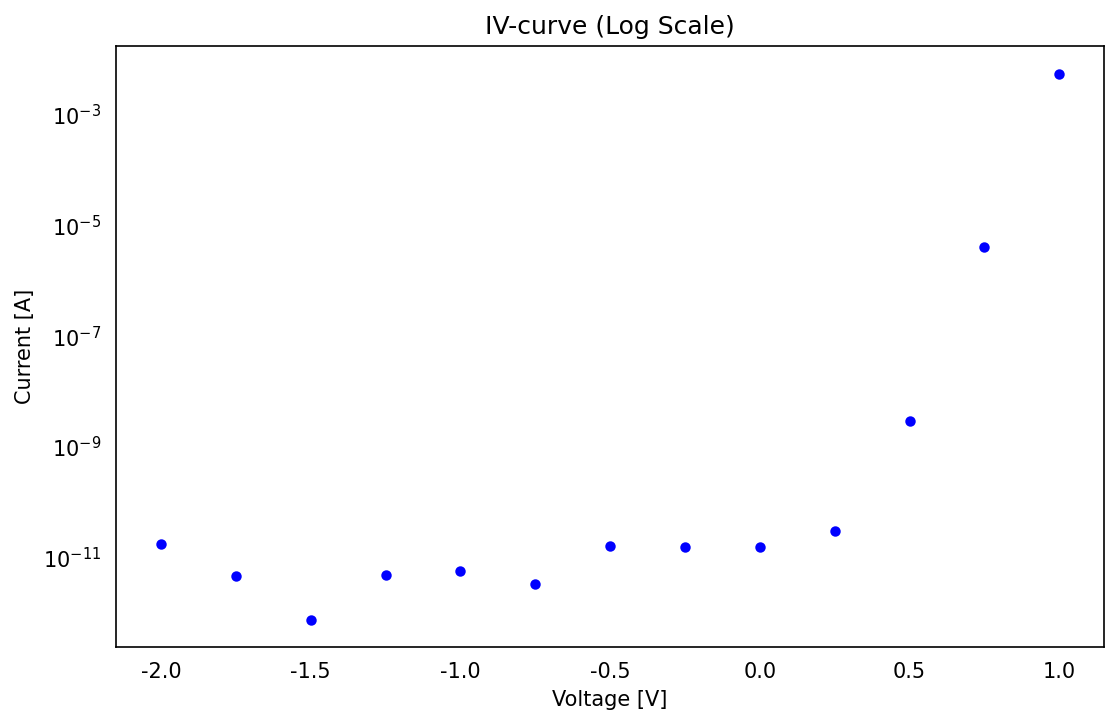

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_iv_log(ax, iv)
show_figure(fig)

### 7.6 IV Analysis Fit

This graph adds fitting diagnostics to the IV curve.

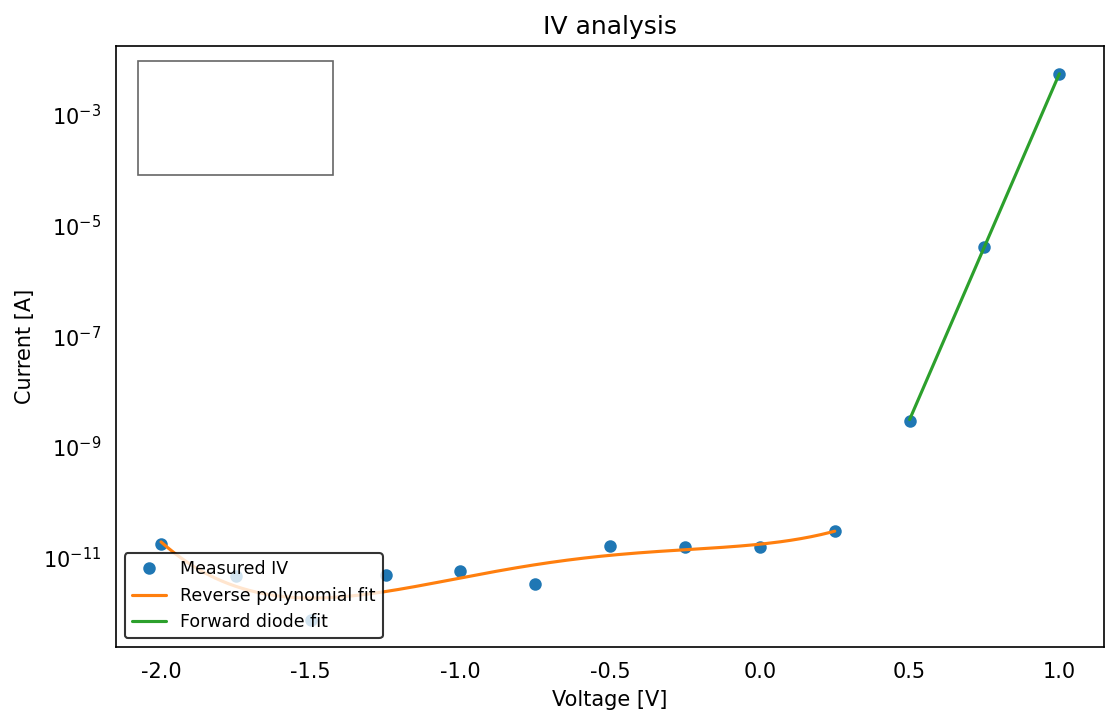

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_iv_analysis(ax, iv)
show_figure(fig)

### 7.7 MZM dB Residual Fit

This graph fits the MZM response in the dB domain after baseline and residual-envelope handling.

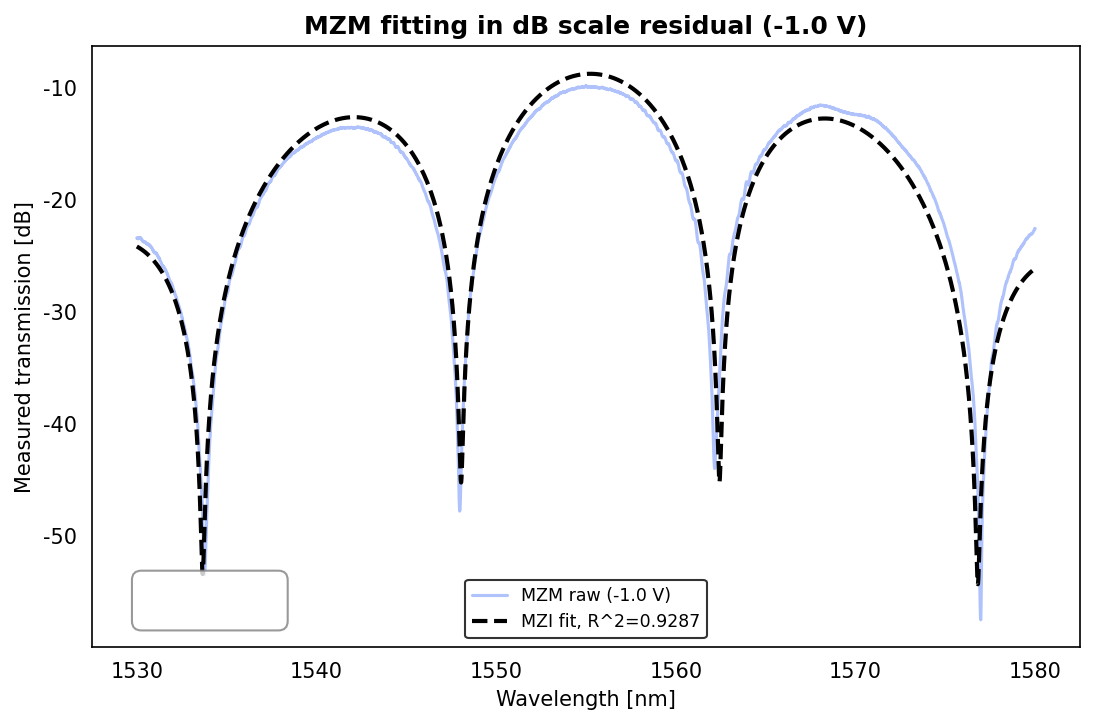

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_mzm_db_residual_fit(ax, sweeps, poly_func, fsr_fallback)
show_figure(fig)

### 7.8 Vpi versus DC Bias

This graph shows extracted half-wave voltage as a function of DC bias.

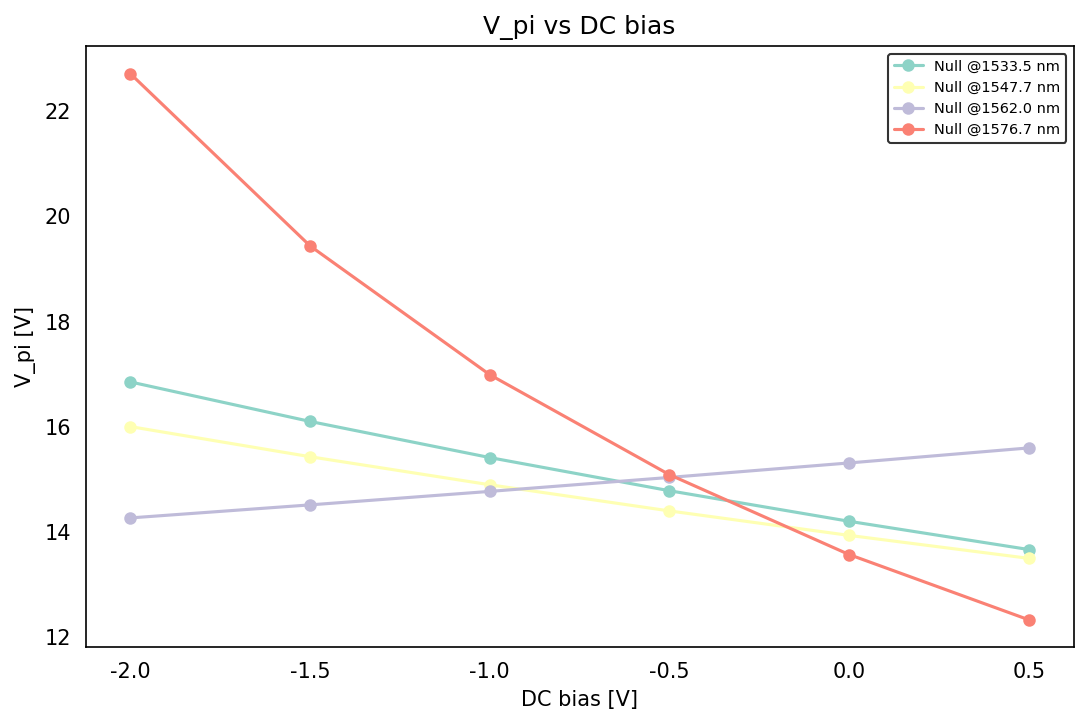

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_vpi_voltage_panels([ax], root)
show_figure(fig)

### 7.9 Extinction Ratio versus DC Bias

This graph summarizes extinction ratio across DC-bias points using mean, minimum, and maximum values.

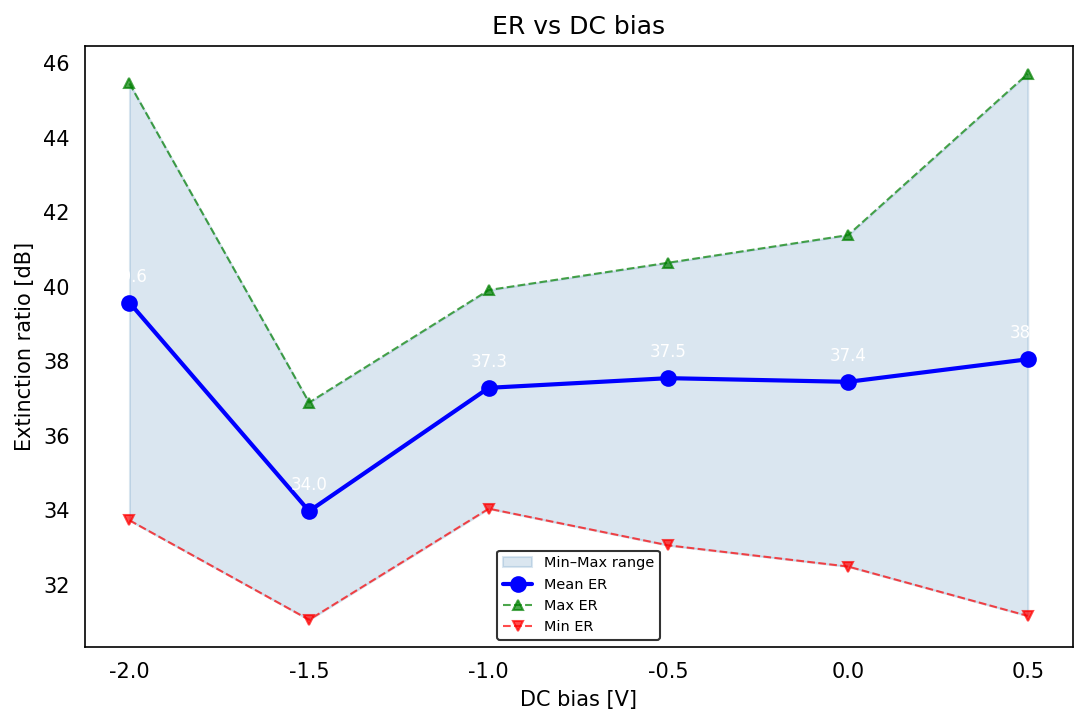

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_extinction_ratio_panels([ax], root)
show_figure(fig)

## 8. Full Die-Level Graph Example

This final section shows the complete die-level multi-panel analysis figure for the same D08 / `20190712_113254` / `(0,0)` die.

This is the compact report-style figure generated by the project pipeline.

Example XML exists: True C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1\data\HY202103\D08\20190712_113254\HY202103_D08_(0,0)_LION1_DCM_LMZC.xml
Example PNG exists: True C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1\res\png\D08\20190712_113254\HY202103_D08_(0,0)_LION1_DCM_LMZC.png


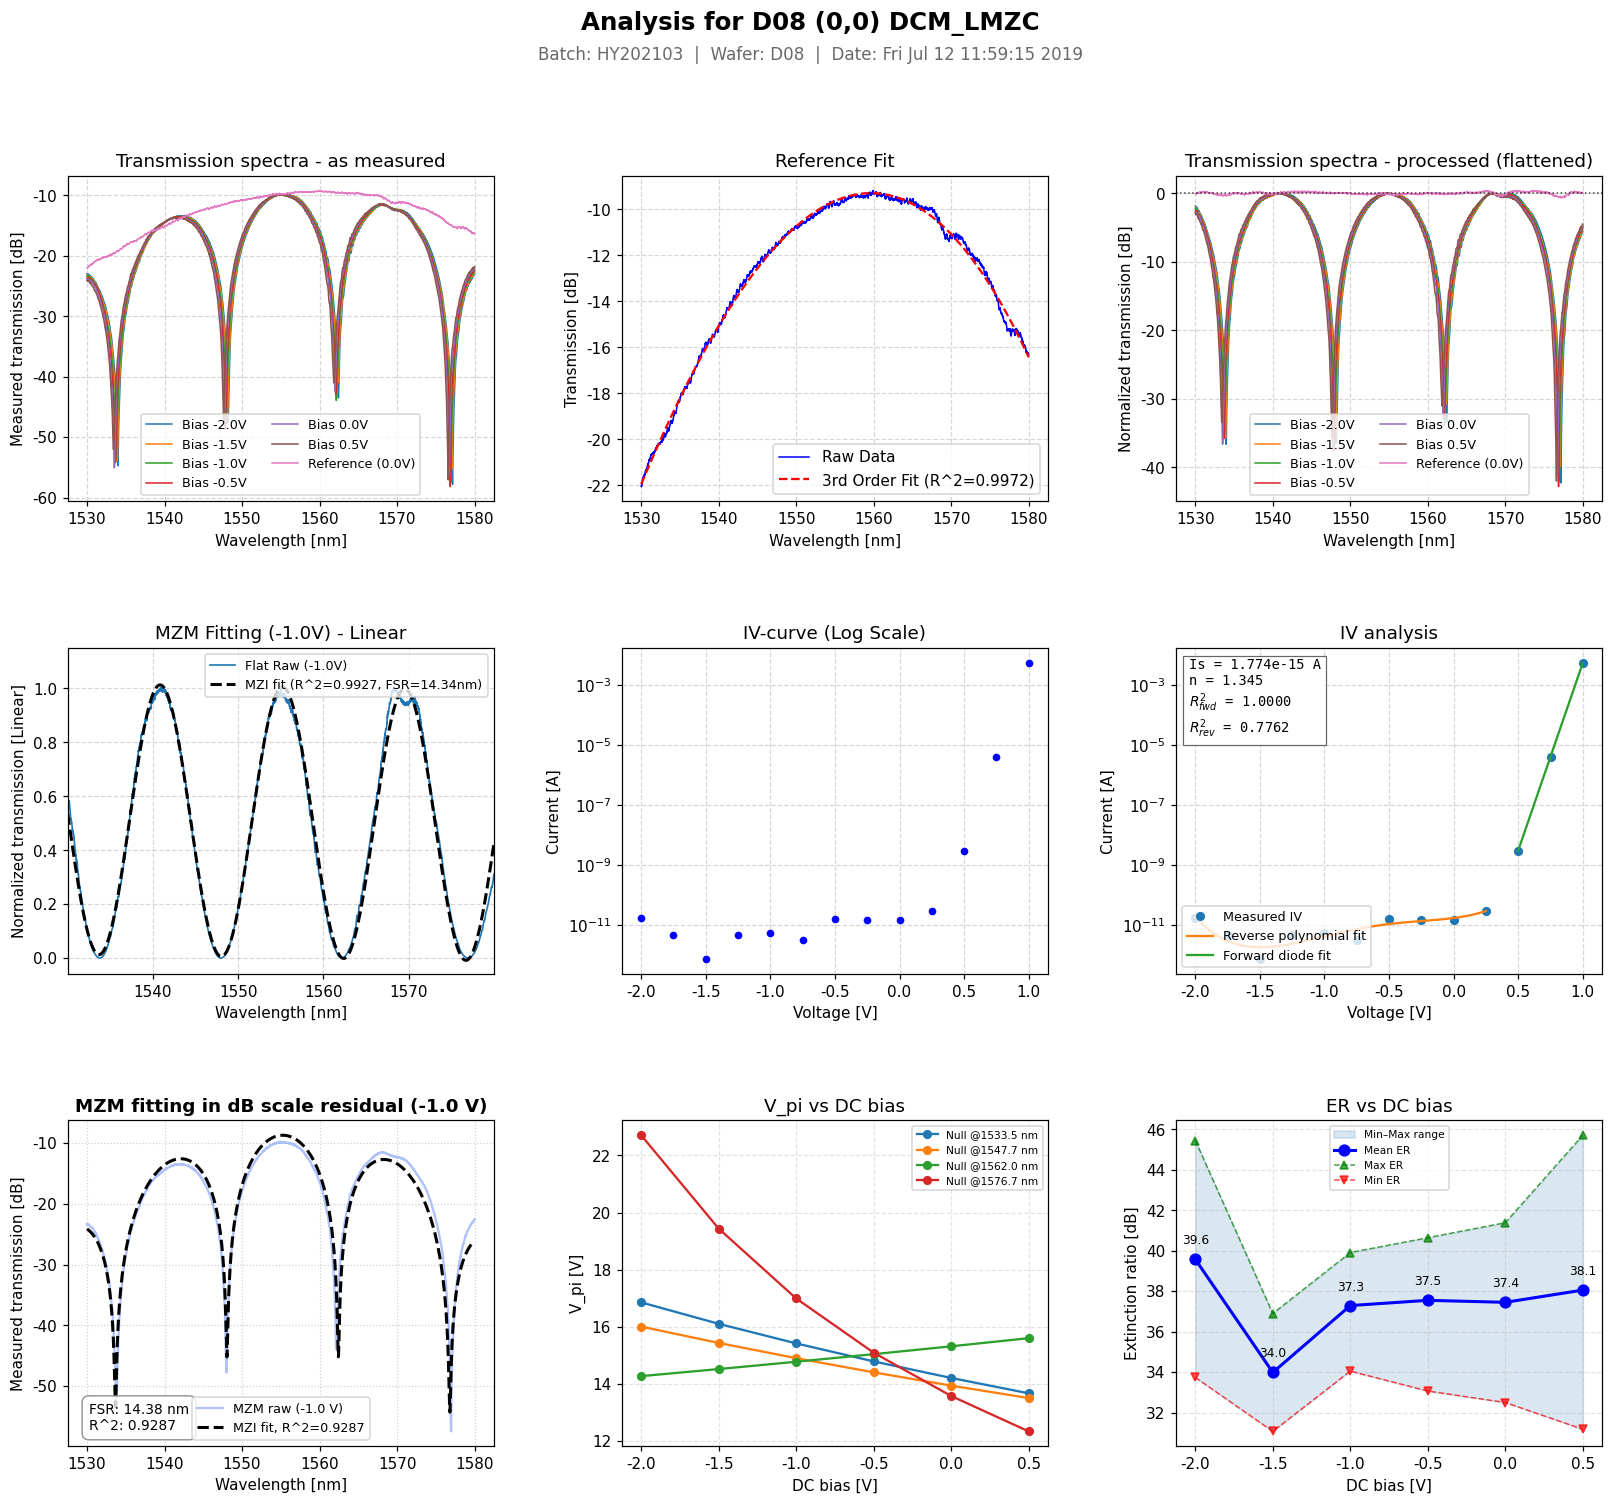

In [16]:
from IPython.display import Image, display
from pathlib import Path

example_xml = PROJECT_ROOT / "data/HY202103/D08/20190712_113254/HY202103_D08_(0,0)_LION1_DCM_LMZC.xml"
example_png = PROJECT_ROOT / "res/png/D08/20190712_113254/HY202103_D08_(0,0)_LION1_DCM_LMZC.png"

print("Example XML exists:", example_xml.exists(), example_xml)
print("Example PNG exists:", example_png.exists(), example_png)

if example_png.exists():
    display(Image(filename=str(example_png)))
else:
    print("The PNG does not exist yet. Run the next cell to generate it from the XML file.")

## 9. Wafermap Example: D08 / 20190712_113254

This section displays the wafer-level summary map for wafer `D08` at timestamp `20190712_113254`.

The wafermap summarizes die-level performance metrics across wafer positions. It is useful for checking spatial uniformity and identifying strong or weak die locations.


Wafermap path: C:\Users\kdm16_korqogl\PycharmProjects\PythonProject1\res\png\D08\20190712_113254\wafermap.png
Exists: True


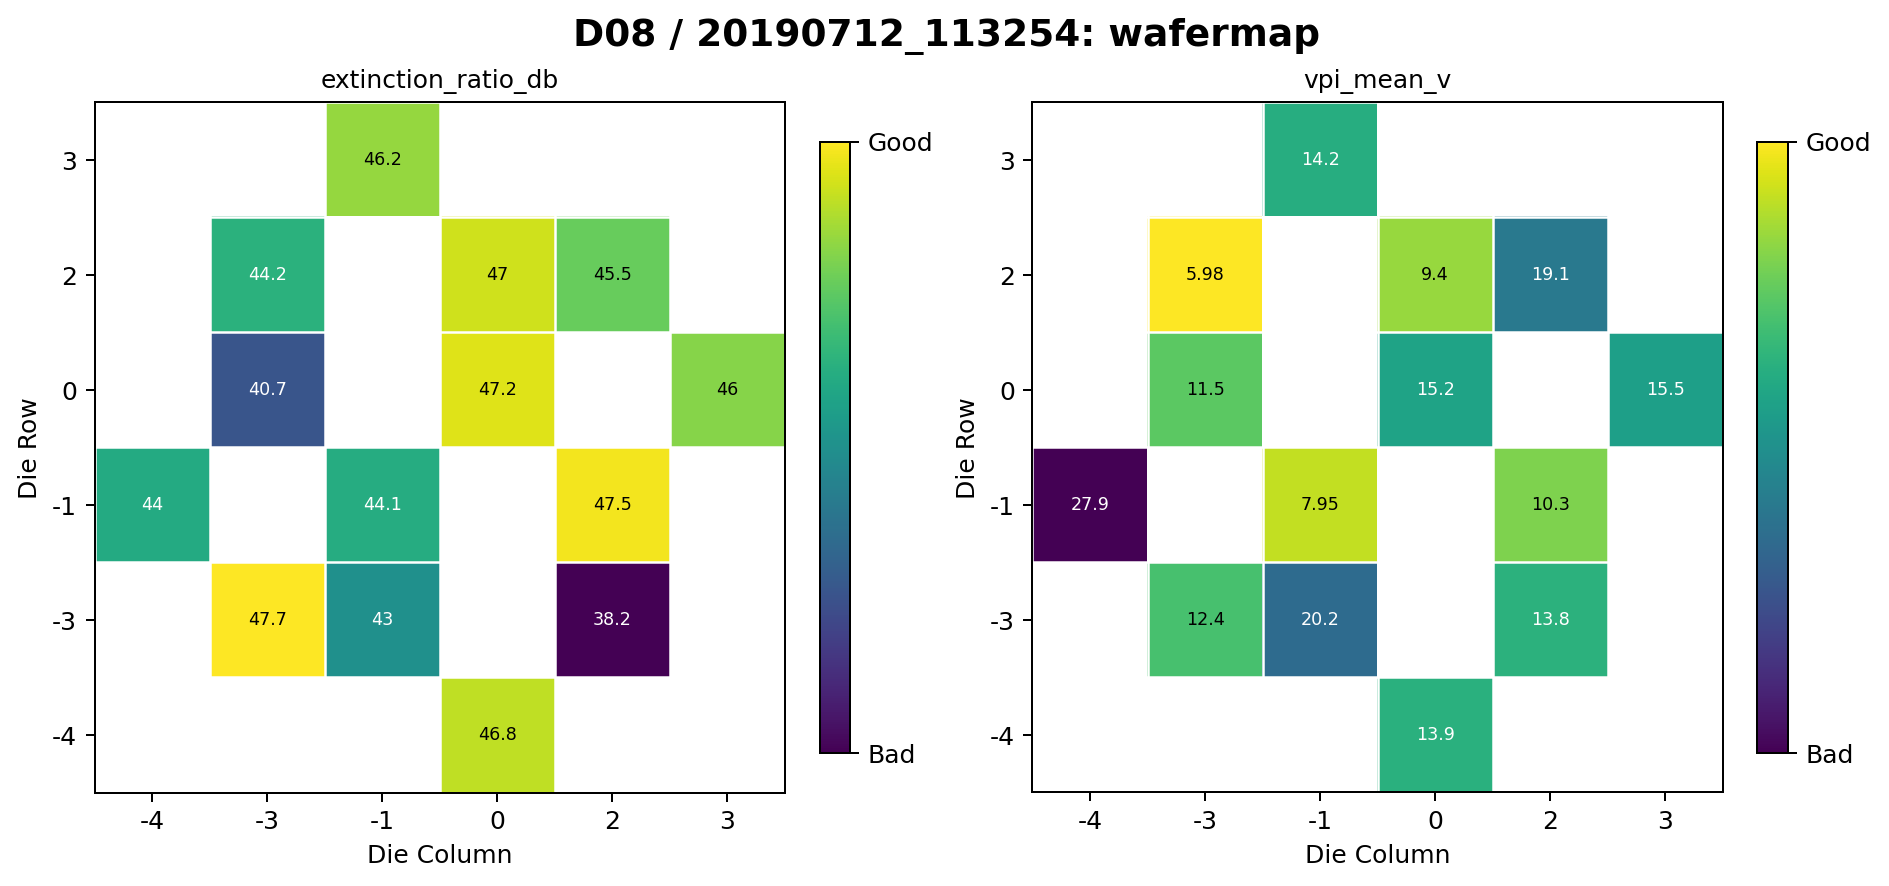

In [17]:
from pathlib import Path
from IPython.display import Image, display

wafermap_png = PROJECT_ROOT / "res/png/D08/20190712_113254/wafermap.png"

print("Wafermap path:", wafermap_png)
print("Exists:", wafermap_png.exists())

if wafermap_png.exists():
    display(Image(filename=str(wafermap_png)))
else:
    print("Wafermap PNG was not found. Run the full analysis pipeline to generate it.")
